# Analyzing DHS microdata

Nigeria 2018 - J:\DATA\DHS_PROG_DHS\NGA\2018
India 2015-2016 - J:\DATA\DHS_PROG_DHS\IND\2015_2016

More recent is available, but probably weird due to COVID

## Documentation

DHS 7 recode manual for variable definitions: https://www.dhsprogram.com/pubs/pdf/DHSG4/Recode7_DHS_10Sep2018_DHSG4.pdf.
However, it does not state which variables are in which file.
The `.MAP` files alongside each data file list the variables in it and what they mean.

Hemoglobin variables of interest: 
- HA53: Hemoglobin level in g/dl with 1 implied dcimal
- HA54: Currently pregnant
- HA55 Result of Hemoglobin measuring.
- HA56 Hemoglobin level adjusted by altitude in g/dl with 1 implied decimal. 

Wealth index variables of interest: 
- HV270: The wealth index is a composite measure of a household's cumulative living standard.
The wealth index is calculated using easy-to-collect data on a household’s ownership of
selected assets, such as televisions and bicycles; materials used for housing construction; and
types of water access and sanitation facilities.
Generated with a statistical procedure known as principal components analysis, the wealth
index places individual households on a continuous scale of relative wealth. DHS separates
all interviewed households into five wealth quintiles to compare the influence of wealth on
various population, health and nutrition indicators. The wealth index is presented in the DHS
Final Reports and survey datasets as a background characteristic
- HV271: Wealth index factor score (5 decimals) 

Pregnancy variables of interest: 
- HML18: Pregnancy status from individual questionnaire. For complete woman’s interviews this is
taken from V213. For incomplete woman's interview with anemia testing the pregnancy
status is taken from this section.
BASE: Women with a completed individual questionnaire or when available information
from the anemia testing section.

List of datasets: https://www.dhsprogram.com/data/dataset/Nigeria_Standard-DHS_2018.cfm?flag=1

Instructions on how to calculate everything can be found at: https://www.dhsprogram.com/pubs/pdf/DHSG1/Guide_to_DHS_Statistics_DHS-7_v2.pdf

In [1]:
import pandas as pd, numpy as np
from lsff_utils import data_processing

%load_ext autoreload
%autoreload 2

!date

Wed Sep  2 10:59:27 PDT 2026


In [2]:
location = "india"

In [3]:
# Parameters
location = "nigeria"


## Load data, name columns

In [4]:
directory = {
    "india": "/snfs1/DATA/DHS_PROG_DHS/IND/2015_2016/",
    "nigeria": "/snfs1/DATA/DHS_PROG_DHS/NGA/2018/",
    "ethiopia": "/snfs1/DATA/DHS_PROG_DHS/ETH/2016/",
}[location]

### WRA

In [5]:
%%time

wra_data_file_name = {
    "india": "IND_DHS7_2015_2016_WN_IAIR74FL_Y2018M12D06.DTA",
    "nigeria": "NGA_DHS7_2018_WN_NGIR7AFL_Y2019M11D05.DTA",
    "ethiopia": "ETH_DHS7_2016_WN_ETIR71FL_Y2019M12D11.DTA",
}[location]

wra_columns = {
    "v001": "cluster_number",
    "v002": "household_number",
    "v003": "line_number",
    "v005": "weight",
    "v008": "interview_date",
    "v011": "date_of_birth",
    "v190": "wealth_quintile",
    "v213": "currently_pregnant",
}
wra_data = pd.read_stata(
    directory + wra_data_file_name,
    columns=wra_columns.keys(),
)

CPU times: user 1.19 s, sys: 709 ms, total: 1.9 s
Wall time: 2.5 s


In [6]:
wra_data = wra_data[wra_columns.keys()].rename(columns=wra_columns)

In [7]:
wra_data["wealth_quintile"] = data_processing.recode_dhs_wealth_quintile(
    wra_data.wealth_quintile
)

In [8]:
wra_data["pregnant"] = wra_data.currently_pregnant.str.strip().map(
    {
        "not pregnant, don't know": "not_pregnant",
        "no or unsure": "not_pregnant",
        "pregnant": "pregnant",
        "yes": "pregnant",
    }
)

In [9]:
wra_data["weight"] = wra_data.weight / 1_000_000

### Births

In [10]:
birth_data_file_name = {
    "india": "IND_DHS7_2015_2016_BR_IABR74FL_Y2018M12D06.DTA",
    "nigeria": "NGA_DHS7_2018_BR_NGBR7AFL_Y2019M11D05.DTA",
    "ethiopia": "ETH_DHS7_2016_BR_ETBR71FL_Y2019M12D11.DTA",
}[location]

birth_columns = {
    "v005": "weight",
    "v008": "interview_date",
    "v190": "wealth_quintile",
    "b3": "birth_date",
    "m18": "size_of_child",
    "m19": "birth_weight_kilograms",
}
if location == "india":
    birth_columns["s220a"] = "duration_of_pregnancy"
else:
    birth_columns["b20"] = "duration_of_pregnancy"

birth_data = pd.read_stata(
    directory + birth_data_file_name,
    columns=birth_columns.keys(),
)
birth_data

,v005,v008,v190,b3,m18,m19,b20
0,1335530,1425,richest,1412,average,3500.0,9.0
1,1335530,1425,richest,1292,NaN,NaN,NaN
2,1335530,1425,richest,1206,NaN,NaN,NaN
3,1335530,1425,richest,1416,very small,2000.0,9.0
4,1335530,1425,richest,1361,NaN,NaN,9.0
...,...,...,...,...,...,...,...
127540,768129,1426,richer,1418,larger than average,3200.0,9.0
127541,768129,1426,richest,1384,very large,4100.0,9.0
127542,768129,1426,richest,1366,NaN,NaN,9.0
127543,768129,1426,richest,1355,NaN,NaN,NaN


In [11]:
birth_data = birth_data[birth_columns.keys()].rename(columns=birth_columns)
birth_data["wealth_quintile"] = data_processing.recode_dhs_wealth_quintile(
    birth_data.wealth_quintile
)
birth_data["weight"] = birth_data.weight / 1_000_000
birth_data

,weight,interview_date,wealth_quintile,birth_date,size_of_child,birth_weight_kilograms,duration_of_pregnancy
0,1.335530,1425,5,1412,average,3500.0,9.0
1,1.335530,1425,5,1292,NaN,NaN,NaN
2,1.335530,1425,5,1206,NaN,NaN,NaN
3,1.335530,1425,5,1416,very small,2000.0,9.0
4,1.335530,1425,5,1361,NaN,NaN,9.0
...,...,...,...,...,...,...,...
127540,0.768129,1426,4,1418,larger than average,3200.0,9.0
127541,0.768129,1426,5,1384,very large,4100.0,9.0
127542,0.768129,1426,5,1366,NaN,NaN,9.0
127543,0.768129,1426,5,1355,NaN,NaN,NaN


### Household members

In [12]:
%%time

hhm_data_file_name = {
    "india": "IND_DHS7_2015_2016_HHM_IAPR74FL_Y2018M12D06.DTA",
    "nigeria": "NGA_DHS7_2018_HHM_NGPR7AFL_Y2019M11D05.DTA",
    "ethiopia": "ETH_DHS7_2016_HHM_ETPR71FL_Y2019M12D11.DTA",
}[location]

hhm_columns = {
    "hv001": "cluster_number",
    "hv002": "household_number",
    "hv005": "weight",
    "hv008": "date_of_interview",
    "hvidx": "line_number",
    "hv105": "age",
    "hv104": "sex",
    "ha0": "index_to_household",
    "ha1": "age_hemoglobin",
    "hv270": "wealth_quintile",
    "ha53": "hemoglobin_raw_adult",
    "ha56": "hemoglobin_adjusted_adult",
    "ha57": "anemia_adult",
    "hc53": "hemoglobin_raw_child",
    "hc56": "hemoglobin_adjusted_child",
    "hc57": "anemia_child",
}
hhm_data = pd.read_stata(
    directory + hhm_data_file_name,
    columns=hhm_columns.keys(),
)
hhm_data

CPU times: user 361 ms, sys: 194 ms, total: 556 ms
Wall time: 941 ms


,hv001,hv002,hv005,hv008,hvidx,hv105,hv104,ha0,ha1,hv270,ha53,ha56,ha57,hc53,hc56,hc57
0,1,1,1368354,1425,1,82,male,NaN,NaN,richest,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1368354,1425,2,40,female,NaN,NaN,richest,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,1368354,1425,3,18,male,NaN,NaN,richest,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1,1368354,1425,4,11,female,NaN,NaN,richest,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1,1368354,1425,5,1,female,NaN,NaN,richest,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188005,1400,45,787007,1426,2,45,female,NaN,NaN,richest,NaN,NaN,NaN,NaN,NaN,NaN
188006,1400,45,787007,1426,3,7,female,NaN,NaN,richest,NaN,NaN,NaN,NaN,NaN,NaN
188007,1400,46,787007,1426,1,20,male,NaN,NaN,richer,NaN,NaN,NaN,NaN,NaN,NaN
188008,1400,46,787007,1426,2,18,male,NaN,NaN,richer,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
hhm_data = hhm_data[hhm_columns.keys()].rename(columns=hhm_columns)

In [14]:
id_columns = ["cluster_number", "household_number", "line_number"]
hhm_data = hhm_data.merge(
    wra_data[id_columns + ["pregnant"]],
    on=id_columns,
    how="left",
)
hhm_data["pregnant"] = hhm_data.pregnant.fillna("not_pregnant")

In [15]:
hhm_data["age"] = hhm_data.age.replace({"95+": 95, "don't know": np.nan}).astype(float)

In [16]:
hhm_data["sex"] = hhm_data.sex.str.title()

In [17]:
# Interesting -- sometimes age is quite off between hemoglobin and base.
hhm_data.loc[(hhm_data.age - hhm_data.age_hemoglobin).sort_values().index]

,cluster_number,household_number,weight,date_of_interview,line_number,age,sex,index_to_household,age_hemoglobin,wealth_quintile,hemoglobin_raw_adult,hemoglobin_adjusted_adult,anemia_adult,hemoglobin_raw_child,hemoglobin_adjusted_child,anemia_child,pregnant
136280,894,61,684320,1425,10,20.0,Female,10.0,48.0,richer,104.0,104.0,moderate,NaN,NaN,NaN,not_pregnant
163597,1158,55,1817765,1425,2,23.0,Female,2.0,48.0,middle,124.0,124.0,not anemic,NaN,NaN,NaN,not_pregnant
120580,774,62,743135,1426,3,25.0,Female,3.0,49.0,richer,143.0,143.0,not anemic,NaN,NaN,NaN,not_pregnant
141539,940,1,1064671,1428,2,30.0,Female,2.0,49.0,middle,104.0,104.0,moderate,NaN,NaN,NaN,not_pregnant
134149,876,44,535338,1425,2,30.0,Female,2.0,48.0,middle,86.0,86.0,moderate,NaN,NaN,NaN,pregnant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188005,1400,45,787007,1426,2,45.0,Female,NaN,NaN,richest,NaN,NaN,NaN,NaN,NaN,NaN,not_pregnant
188006,1400,45,787007,1426,3,7.0,Female,NaN,NaN,richest,NaN,NaN,NaN,NaN,NaN,NaN,not_pregnant
188007,1400,46,787007,1426,1,20.0,Male,NaN,NaN,richer,NaN,NaN,NaN,NaN,NaN,NaN,not_pregnant
188008,1400,46,787007,1426,2,18.0,Male,NaN,NaN,richer,NaN,NaN,NaN,NaN,NaN,NaN,not_pregnant


In [18]:
(hhm_data.age - hhm_data.age_hemoglobin).describe()

count    15452.000000
mean        -0.408232
std          2.393453
min        -28.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         25.000000
dtype: float64

In [19]:
age_bin_edges = [0, 5, 15, 30, 50, 125]
age_group = pd.IntervalIndex(
    pd.cut(hhm_data.age, age_bin_edges, right=False, include_lowest=True)
)
hhm_data["age_start"] = age_group.left
hhm_data["age_end"] = age_group.right

In [20]:
hhm_data["wealth_quintile"] = data_processing.recode_dhs_wealth_quintile(
    hhm_data.wealth_quintile
)
hhm_data["weight"] = hhm_data.weight / 1_000_000

In [21]:
for type in ["child", "adult"]:
    for base_col in ["hemoglobin_raw", "hemoglobin_adjusted"]:
        col = f"{base_col}_{type}"
        hhm_data[col] = (
            hhm_data[col]
            .astype(str)
            .replace(
                {
                    "not tested": np.nan,
                    "not present": np.nan,
                    "refused": np.nan,
                    "other": np.nan,
                }
            )
            .astype(float)
        )

In [22]:
for base_col in ["hemoglobin_raw", "hemoglobin_adjusted", "anemia"]:
    assert (hhm_data.filter(like=base_col).notnull().sum(axis=1) <= 1).all()
    hhm_data[base_col] = np.nan
    # Could use bfill instead of this loop, but it was incredibly slow for me
    for col in hhm_data.filter(like=base_col).columns:
        hhm_data[base_col] = hhm_data[base_col].fillna(hhm_data[col])

In [23]:
assert (
    hhm_data[(hhm_data.sex == "male") & (hhm_data.age > 5)]
    .hemoglobin_raw.isnull()
    .all()
)

## Hemoglobin

In [24]:
other_overlapping_columns = (
    (set(wra_data.columns) & set(hhm_data.columns)) - set(id_columns) - {"weight"}
)
other_overlapping_columns

{'pregnant', 'wealth_quintile'}

In [25]:
wra_hhm_joined = wra_data.merge(
    hhm_data.drop(columns=["weight"]),
    on=id_columns,
    suffixes=("_wra", "_hhm"),
    how="left",
)
wra_hhm_joined

,cluster_number,household_number,line_number,weight,interview_date,date_of_birth,wealth_quintile_wra,currently_pregnant,pregnant_wra,date_of_interview,...,anemia_adult,hemoglobin_raw_child,hemoglobin_adjusted_child,anemia_child,pregnant_hhm,age_start,age_end,hemoglobin_raw,hemoglobin_adjusted,anemia
0,1,1,2,1.335530,1425,939,5,no or unsure,not_pregnant,1425,...,NaN,NaN,NaN,NaN,not_pregnant,30.0,50.0,NaN,NaN,NaN
1,1,6,4,1.335530,1425,1230,5,no or unsure,not_pregnant,1425,...,not anemic,NaN,NaN,NaN,not_pregnant,15.0,30.0,127.0,127.0,not anemic
2,1,11,1,1.335530,1425,977,5,no or unsure,not_pregnant,1425,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
3,1,25,2,1.335530,1425,1091,5,no or unsure,not_pregnant,1425,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
4,1,30,1,1.335530,1425,1073,5,no or unsure,not_pregnant,1425,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41816,1400,35,3,0.768129,1426,1203,4,no or unsure,not_pregnant,1426,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
41817,1400,35,7,0.768129,1426,1165,4,no or unsure,not_pregnant,1426,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN
41818,1400,38,2,0.768129,1426,1164,4,no or unsure,not_pregnant,1426,...,not anemic,NaN,NaN,NaN,not_pregnant,15.0,30.0,123.0,123.0,not anemic
41819,1400,40,1,0.768129,1426,1119,5,no or unsure,not_pregnant,1426,...,NaN,NaN,NaN,NaN,not_pregnant,15.0,30.0,NaN,NaN,NaN


In [26]:
for col in other_overlapping_columns:
    assert (wra_hhm_joined[f"{col}_wra"] == wra_hhm_joined[f"{col}_hhm"]).all()
    wra_hhm_joined[col] = wra_hhm_joined[f"{col}_wra"]
    wra_hhm_joined = wra_hhm_joined.drop(columns=[f"{col}_wra", f"{col}_hhm"])

In [27]:
# https://stackoverflow.com/a/2415343/ with some tweaks
def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    is_nan = np.isnan(values)
    values = values[~is_nan]
    weights = weights[~is_nan]
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values - average) ** 2, weights=weights)
    return pd.Series(
        {
            "mean": average,
            "sd": np.sqrt(variance),
            # https://ngreifer.github.io/WeightIt/reference/ESS.html
            "effective_sample_size": (weights.sum() ** 2) / (weights**2).sum(),
        }
    )

In [28]:
pregnant_with_anemia_status = wra_hhm_joined[
    (wra_hhm_joined.pregnant == "pregnant") & wra_hhm_joined.anemia.notnull()
]

In [29]:
# Matches table 10.21.1
pregnant_with_anemia_status.weight.sum()

1541.655271

In [30]:
# Within rounding error of table 10.21.1 value
weighted_avg_and_std(
    pregnant_with_anemia_status.anemia == "severe",
    pregnant_with_anemia_status.weight,
)

mean                        0.022881
sd                          0.149524
effective_sample_size    1051.325248
dtype: float64

In [31]:
# Within rounding error of table 10.21.1 value for any anemia
weighted_avg_and_std(
    pregnant_with_anemia_status.anemia.isin(["severe", "moderate", "mild"]),
    pregnant_with_anemia_status.weight,
)

mean                        0.611143
sd                          0.487491
effective_sample_size    1051.325248
dtype: float64

In [32]:
assert (
    (pregnant_with_anemia_status.anemia == "severe")
    == (pregnant_with_anemia_status.hemoglobin_adjusted < 70)
).all()

In [33]:
assert (
    (pregnant_with_anemia_status.anemia.isin(["severe", "moderate", "mild"]))
    == (pregnant_with_anemia_status.hemoglobin_adjusted < 110)
).all()

In [34]:
adult_hemoglobin_disparities = (
    wra_hhm_joined.groupby(["wealth_quintile", "pregnant"])
    .apply(lambda df: weighted_avg_and_std(df.hemoglobin_adjusted, weights=df.weight))
    .sort_index()
)
adult_hemoglobin_disparities

mean         sd  effective_sample_size
wealth_quintile pregnant                                                  
1               not_pregnant  113.444966  15.148809            1750.492248
                pregnant      103.539139  15.210946             276.303313
2               not_pregnant  115.420130  14.920351            1843.222455
                pregnant      102.462408  16.636787             287.600823
3               not_pregnant  116.087185  15.108541            2138.470509
                pregnant      104.689267  15.828476             230.053871
4               not_pregnant  116.578539  14.792239            1756.765695
                pregnant      107.325694  16.717644             152.638702
5               not_pregnant  118.793246  14.222341            1689.669203
                pregnant      108.476993  15.277522             140.496508

In [35]:
adult_hemoglobin_disparities = adult_hemoglobin_disparities.reset_index()
adult_hemoglobin_disparities = pd.concat(
    [
        adult_hemoglobin_disparities.assign(sex="Female", age_start=15, age_end=125),
        # Assumption: males are like non-pregnant WRA
        adult_hemoglobin_disparities[
            adult_hemoglobin_disparities.pregnant == "not_pregnant"
        ].assign(sex="Male", age_start=15, age_end=125),
    ]
)
adult_hemoglobin_disparities = adult_hemoglobin_disparities.set_index(
    ["sex", "age_start", "age_end", "pregnant", "wealth_quintile"]
)
adult_hemoglobin_disparities

mean         sd  \
sex    age_start age_end pregnant     wealth_quintile                          
Female 15        125     not_pregnant 1                113.444966  15.148809   
                         pregnant     1                103.539139  15.210946   
                         not_pregnant 2                115.420130  14.920351   
                         pregnant     2                102.462408  16.636787   
                         not_pregnant 3                116.087185  15.108541   
                         pregnant     3                104.689267  15.828476   
                         not_pregnant 4                116.578539  14.792239   
                         pregnant     4                107.325694  16.717644   
                         not_pregnant 5                118.793246  14.222341   
                         pregnant     5                108.476993  15.277522   
Male   15        125     not_pregnant 1                113.444966  15.148809   
                                      2                115.420130  14.920351   
                                      3                116.087185  15.108541   
                                      4                116.578539  14.792239   
                                      5                118.793246  14.222341   

                                                       effective_sample_size  
sex    age_start age_end pregnant     wealth_quintile                         
Female 15        125     not_pregnant 1                          1750.492248  
                         pregnant     1                           276.303313  
                         not_pregnant 2                          1843.222455  
                         pregnant     2                           287.600823  
                         not_pregnant 3                          2138.470509  
                         pregnant     3                           230.053871  
                         not_pregnant 4                          1756.765695  
                         pregnant     4                           152.638702  
                         not_pregnant 5                          1689.669203  
                         pregnant     5                           140.496508  
Male   15        125     not_pregnant 1                          1750.492248  
                                      2                          1843.222455  
                                      3                          2138.470509  
                                      4                          1756.765695  
                                      5                          1689.669203

In [36]:
child_hemoglobin_disparities = (
    hhm_data[(hhm_data.age <= 5)]
    .assign(age_start=0, age_end=5, pregnant="not_pregnant")
    .groupby(["sex", "age_start", "age_end", "pregnant", "wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.hemoglobin_adjusted, weights=df.weight))
    .sort_index()
)
child_hemoglobin_disparities

mean         sd  \
sex    age_start age_end pregnant     wealth_quintile                          
Female 0         5       not_pregnant 1                 97.093264  16.607283   
                                      2                 99.647180  15.898899   
                                      3                102.658490  15.268520   
                                      4                103.792784  14.286274   
                                      5                107.778540  13.194608   
Male   0         5       not_pregnant 1                 94.491330  16.224485   
                                      2                 97.899847  15.872407   
                                      3                101.777578  15.215238   
                                      4                101.925837  14.556531   
                                      5                107.678544  12.543715   

                                                       effective_sample_size  
sex    age_start age_end pregnant     wealth_quintile                         
Female 0         5       not_pregnant 1                           903.485656  
                                      2                           840.611218  
                                      3                           908.937459  
                                      4                           762.800255  
                                      5                           648.728190  
Male   0         5       not_pregnant 1                           925.419674  
                                      2                           828.777224  
                                      3                           947.992726  
                                      4                           761.414410  
                                      5                           628.727378

In [37]:
adolescent_hemoglobin_disparities = pd.DataFrame(
    columns=child_hemoglobin_disparities.columns,
    index=child_hemoglobin_disparities.index,
).droplevel(["age_start", "age_end"])
for group in adolescent_hemoglobin_disparities.index:
    child_values = child_hemoglobin_disparities.droplevel(["age_start", "age_end"]).loc[
        group
    ]
    adult_values = adult_hemoglobin_disparities.droplevel(["age_start", "age_end"]).loc[
        group
    ]
    adolescent_hemoglobin_disparities.loc[group] = (
        child_values * 0.5 + adult_values * 0.5
    ).T

In [38]:
assert adolescent_hemoglobin_disparities.notnull().all().all()
adolescent_hemoglobin_disparities = (
    adolescent_hemoglobin_disparities.reset_index()
    .assign(age_start=5, age_end=15)
    .set_index(list(child_hemoglobin_disparities.index.names))
)

In [39]:
hemoglobin_disparities = pd.concat(
    [
        child_hemoglobin_disparities,
        adolescent_hemoglobin_disparities,
        adult_hemoglobin_disparities,
    ]
)
hemoglobin_disparities

mean         sd  \
sex    age_start age_end pregnant     wealth_quintile                          
Female 0         5       not_pregnant 1                 97.093264  16.607283   
                                      2                  99.64718  15.898899   
                                      3                 102.65849   15.26852   
                                      4                103.792784  14.286274   
                                      5                 107.77854  13.194608   
Male   0         5       not_pregnant 1                  94.49133  16.224485   
                                      2                 97.899847  15.872407   
                                      3                101.777578  15.215238   
                                      4                101.925837  14.556531   
                                      5                107.678544  12.543715   
Female 5         15      not_pregnant 1                105.269115  15.878046   
                                      2                107.533655  15.409625   
                                      3                109.372837   15.18853   
                                      4                110.185662  14.539256   
                                      5                113.285893  13.708475   
Male   5         15      not_pregnant 1                103.968148  15.686647   
                                      2                106.659989  15.396379   
                                      3                108.932381  15.161889   
                                      4                109.252188  14.674385   
                                      5                113.235895  13.383028   
Female 15        125     not_pregnant 1                113.444966  15.148809   
                         pregnant     1                103.539139  15.210946   
                         not_pregnant 2                 115.42013  14.920351   
                         pregnant     2                102.462408  16.636787   
                         not_pregnant 3                116.087185  15.108541   
                         pregnant     3                104.689267  15.828476   
                         not_pregnant 4                116.578539  14.792239   
                         pregnant     4                107.325694  16.717644   
                         not_pregnant 5                118.793246  14.222341   
                         pregnant     5                108.476993  15.277522   
Male   15        125     not_pregnant 1                113.444966  15.148809   
                                      2                 115.42013  14.920351   
                                      3                116.087185  15.108541   
                                      4                116.578539  14.792239   
                                      5                118.793246  14.222341   

                                                      effective_sample_size  
sex    age_start age_end pregnant     wealth_quintile                        
Female 0         5       not_pregnant 1                          903.485656  
                                      2                          840.611218  
                                      3                          908.937459  
                                      4                          762.800255  
                                      5                           648.72819  
Male   0         5       not_pregnant 1                          925.419674  
                                      2                          828.777224  
                                      3                          947.992726  
                                      4                           761.41441  
                                      5                          628.727378  
Female 5         15      not_pregnant 1                         1326.988952  
                                      2                         1341.916837  
        

In [40]:
results_dir = "../results"

In [41]:
hemoglobin_disparities["mean"].rename("value").to_csv(
    f"{results_dir}/hemoglobin/mean_disparities/{location}.csv"
)

In [42]:
hemoglobin_disparities["sd"].rename("value").to_csv(
    f"{results_dir}/hemoglobin/sd_disparities/{location}.csv"
)

## Wealth quintile probabilities

Intuitively, you might think these would be equal; but we are looking at subpopulations which can skew.

In [43]:
group_variables = ["sex", "age_start", "age_end", "pregnant"]

In [44]:
wealth_quintile_probabilities = (
    hhm_data.groupby(group_variables + ["wealth_quintile"], observed=True).weight.sum()
    / hhm_data.groupby(group_variables, observed=True).weight.sum()
)
assert np.allclose(
    wealth_quintile_probabilities.groupby(group_variables, observed=True).sum(), 1.0
)
wealth_quintile_probabilities

sex     age_start  age_end  pregnant      wealth_quintile
Female  0.0        5.0      not_pregnant  1                  0.220707
                                          2                  0.219801
                                          3                  0.207518
                                          4                  0.182416
                                          5                  0.169557
        5.0        15.0     not_pregnant  1                  0.222903
                                          2                  0.211314
                                          3                  0.200941
                                          4                  0.189893
                                          5                  0.174949
        15.0       30.0     not_pregnant  1                  0.165248
                                          2                  0.194708
                                          3                  0.200403
                                

In [45]:
wealth_quintile_probabilities = wealth_quintile_probabilities.unstack()
wealth_quintile_probabilities

wealth_quintile                               1         2         3         4  \
sex    age_start age_end pregnant                                               
Female 0.0       5.0     not_pregnant  0.220707  0.219801  0.207518  0.182416   
       5.0       15.0    not_pregnant  0.222903  0.211314  0.200941  0.189893   
       15.0      30.0    not_pregnant  0.165248  0.194708  0.200403  0.223650   
                         pregnant      0.229568  0.269087  0.218290  0.169175   
       30.0      50.0    not_pregnant  0.167414  0.176150  0.188366  0.214621   
                         pregnant      0.247900  0.197054  0.182014  0.163763   
       50.0      125.0   not_pregnant  0.196077  0.184902  0.228885  0.192974   
Male   0.0       5.0     not_pregnant  0.214963  0.223211  0.203137  0.188194   
       5.0       15.0    not_pregnant  0.227134  0.211917  0.202795  0.189340   
       15.0      30.0    not_pregnant  0.194480  0.197231  0.196587  0.211924   
       30.0      50.0    not_pregnant  0.155586  0.166481  0.189007  0.217201   
       50.0      125.0   not_pregnant  0.209864  0.183658  0.188784  0.202148   

wealth_quintile                               5  
sex    age_start age_end pregnant                
Female 0.0       5.0     not_pregnant  0.169557  
       5.0       15.0    not_pregnant  0.174949  
       15.0      30.0    not_pregnant  0.215992  
                         pregnant      0.113880  
       30.0      50.0    not_pregnant  0.253449  
                         pregnant      0.209268  
       50.0      125.0   not_pregnant  0.197161  
Male   0.0       5.0     not_pregnant  0.170495  
       5.0       15.0    not_pregnant  0.168813  
       15.0      30.0    not_pregnant  0.199779  
       30.0      50.0    not_pregnant  0.271724  
       50.0      125.0   not_pregnant  0.215546

Text(0.5, 1.0, 'Wealth quintile probabilities for pregnancies in females 15-30 in Nigeria DHS')

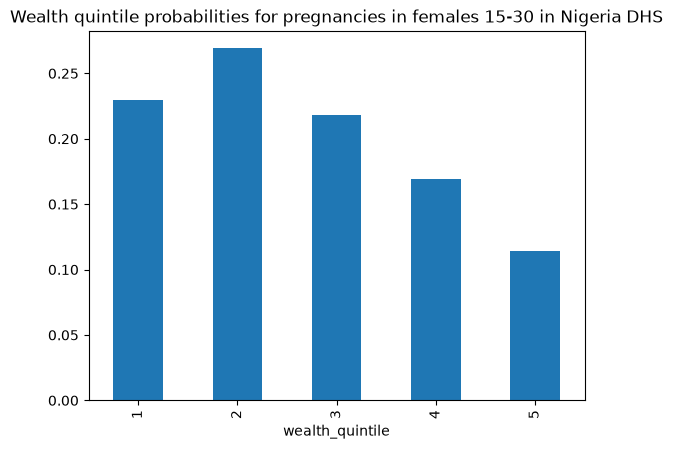

In [46]:
ax = wealth_quintile_probabilities.loc[("Female", 15.0, 30.0, "pregnant")].plot(
    kind="bar"
)
ax.set_title(
    f"Wealth quintile probabilities for pregnancies in females 15-30 in {location.title()} DHS"
)

In [47]:
wealth_quintile_probabilities.to_csv(
    f"{results_dir}/wealth_quintile_probabilities/{location}.csv",
)

## LBWSG

### Birth weight

In [48]:
birth_data["birth_weight_kilograms"] = birth_data.birth_weight_kilograms.replace(
    {"not weighed at birth": np.nan, "don't know": np.nan}
).astype(float)

In [49]:
weighted_avg_and_std(birth_data.birth_weight_kilograms, birth_data.weight)

mean                     3299.147414
sd                        707.273282
effective_sample_size    5305.202402
dtype: float64

In [50]:
birth_weight_disparities = birth_data.groupby("wealth_quintile").apply(
    lambda df: weighted_avg_and_std(df.birth_weight_kilograms, df.weight)
)
birth_weight_disparities

,mean,sd,effective_sample_size
wealth_quintile,,,
1,3101.945903,792.410386,205.122115
2,3199.202134,697.958921,456.582653
3,3236.792039,689.177927,1125.018749
4,3303.292167,742.096221,1437.590223
5,3346.780999,680.939184,2197.873039


In [51]:
birth_weight_disparities = (
    birth_weight_disparities["mean"].rename("value").reset_index()
)
birth_weight_disparities

,wealth_quintile,value
0,1,3101.945903
1,2,3199.202134
2,3,3236.792039
3,4,3303.292167
4,5,3346.780999


In [52]:
birth_weight_disparities.to_csv(
    f"{results_dir}/birth_weight_disparities/{location}.csv", index=False
)

### Short gestation

All we have here is a self-reported duration of pregnancy.

In [53]:
# Basically no difference in mean
birth_data.groupby("wealth_quintile").apply(
    lambda df: weighted_avg_and_std(df.duration_of_pregnancy, df.weight)
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,8.988126,0.214534,7518.541898
2,8.993685,0.178924,6707.127847
3,8.992310,0.248646,5954.834509
4,8.993156,0.227106,4468.346787
5,8.992973,0.252639,3804.565484


In [54]:
birth_data["short_gestation"] = np.where(
    birth_data.duration_of_pregnancy.isnull(),
    np.nan,
    birth_data.duration_of_pregnancy < 9.0,
)

In [55]:
weighted_avg_and_std(birth_data.short_gestation, birth_data.weight)

mean                         0.010840
sd                           0.103547
effective_sample_size    28001.459188
dtype: float64

In [56]:
birth_data.groupby("wealth_quintile").apply(
    lambda df: weighted_avg_and_std(df.short_gestation, df.weight)
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,0.007899,0.088526,7518.541898
2,0.006845,0.082449,6707.127847
3,0.011858,0.108248,5954.834509
4,0.012424,0.110768,4468.346787
5,0.017508,0.131156,3804.565484


The trends in short gestation don't make intuitive sense (?), so we do not plan to use them in the sim.